
Data Overview:
Total Sample Size (Incidents): 613,781
Geographic Unit: Point-level coordinates (Latitude/Longitude) within Memphis, TN
Time Span: From 2020-01-01 to 2026-04-05
------------------------------


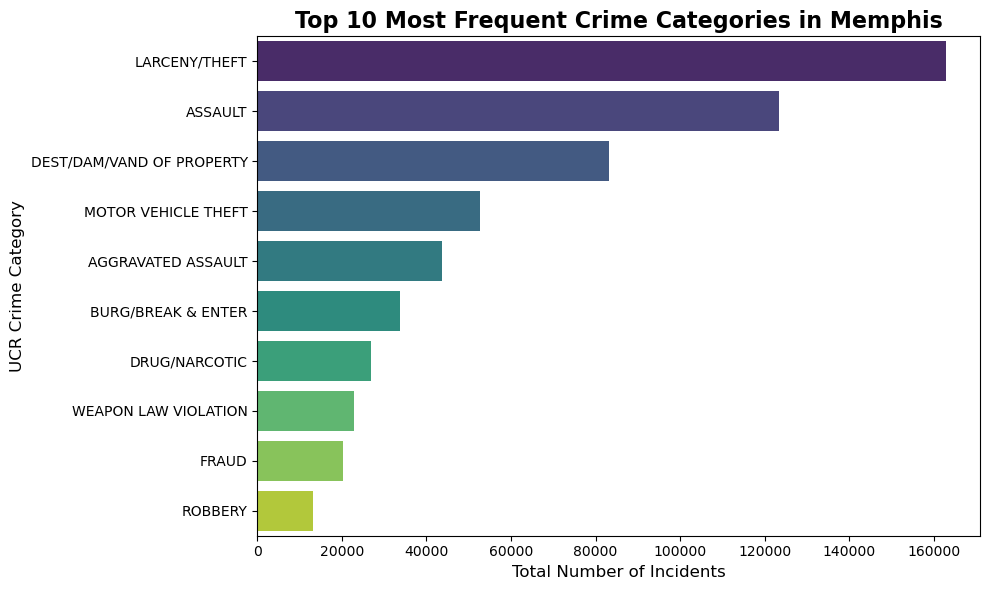

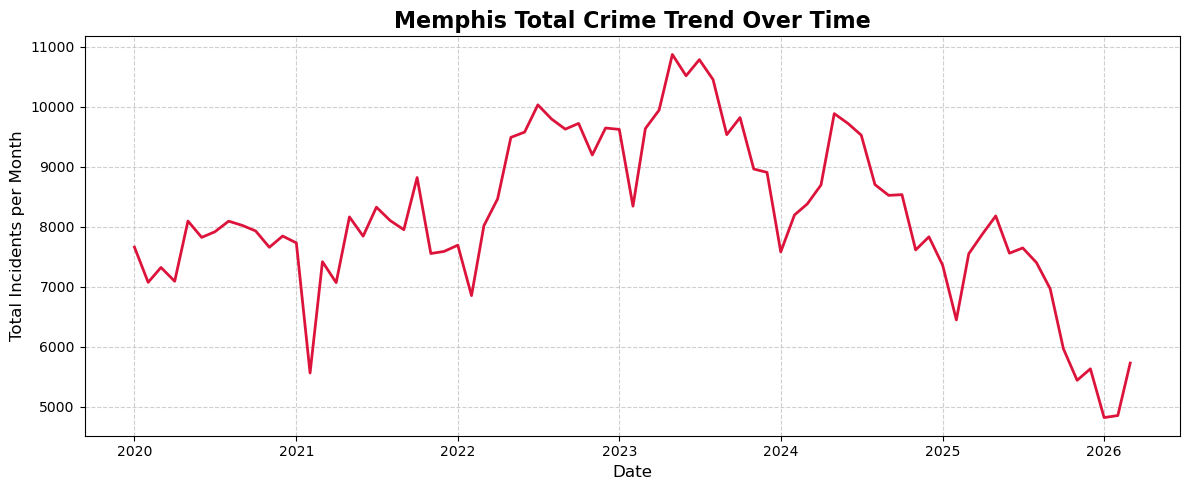

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the MPD dataset
df = pd.read_csv("MPD_Public_Safety_Incidents.csv", low_memory=False)

print("\nData Overview:")
print(f"Total Sample Size (Incidents): {df.shape[0]:,}")
print(f"Geographic Unit: Point-level coordinates (Latitude/Longitude) within Memphis, TN")

#clean the Date Column and find the Time Span
df['Offense Datetime'] = pd.to_datetime(df['Offense Datetime'], errors='coerce')

#drop any rows where the date failed to parse so our timeline is clean
df = df.dropna(subset=['Offense Datetime'])

min_date = df['Offense Datetime'].min().strftime('%Y-%m-%d')
max_date = df['Offense Datetime'].max().strftime('%Y-%m-%d')

print(f"Time Span: From {min_date} to {max_date}")
print("-" * 30)

#plot the top crime categories
plt.figure(figsize=(10, 6))
top_crimes = df['UCR Category'].value_counts().head(10)

#create horizontal bar chart
sns.barplot(x=top_crimes.values, y=top_crimes.index, hue=top_crimes.index, palette="viridis", legend=False)
plt.title("Top 10 Most Frequent Crime Categories in Memphis", fontsize=16, fontweight='bold')
plt.xlabel("Total Number of Incidents", fontsize=12)
plt.ylabel("UCR Crime Category", fontsize=12)
plt.tight_layout()
plt.show()

#plot crime volume over time
plt.figure(figsize=(12, 5))

#group by Year and Month to smooth the trend out
df['YearMonth'] = df['Offense Datetime'].dt.to_period('M')
monthly_crime = df.groupby('YearMonth').size()
monthly_crime = monthly_crime[:-1]

monthly_crime.index = monthly_crime.index.to_timestamp()

#plot the timeline
plt.plot(monthly_crime.index, monthly_crime.values, color='crimson', linewidth=2)
plt.title("Memphis Total Crime Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Incidents per Month", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import requests

#ACS 5-Year Estimates for (2022)
year = "2022"
dataset = "acs/acs5"
state_fips = "47"   #Tennessee
county_fips = "157" #Shelby County

#List of census variables to be used
raw_vars = [
    "NAME", 
    "B01003_001E", "B01002_001E", "B19013_001E", "B19083_001E", #Core Demographics & Income
    "B17001_001E", "B17001_002E", "B23025_003E", "B23025_005E", #Poverty & Unemployment
    "B25002_001E", "B25002_003E", "B25003_001E", "B25003_003E", #Housing (Vacancy & Renter)
    "B11001_001E", "B11005_007E",                               #Family Structure
    "B22010_001E", "B22010_002E",                               #SNAP / Food Stamps
    "B08201_001E", "B08201_002E",                               #Vehicle Access
    "B07001_001E", "B07001_017E",                               #Transience (Mobility)
    "B28002_001E", "B28002_013E",                               #Internet Access
    "B06009_001E", "B06009_002E", "B06009_005E"                 #Education (Base 25+, Dropout, Bachelors)
]
variables = ",".join(raw_vars)

url = f"https://api.census.gov/data/{year}/{dataset}?get={variables}&for=tract:*&in=state:{state_fips}+county:{county_fips}"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    headers = data.pop(0)
    census_df = pd.DataFrame(data, columns=headers)

    #rename raw variables to readable names
    census_df = census_df.rename(columns={
        "B01003_001E": "Total_Population",
        "B01002_001E": "Median_Age",
        "B19013_001E": "Median_Income",
        "B19083_001E": "Gini_Index",
        "B17001_001E": "Pop_Poverty_Base",
        "B17001_002E": "Pop_Below_Poverty",
        "B23025_003E": "Labor_Force",
        "B23025_005E": "Unemployed",
        "B25002_001E": "Total_Housing_Units",
        "B25002_003E": "Vacant_Housing_Units",
        "B25003_001E": "Total_Occupied_Units",
        "B25003_003E": "Renter_Occupied_Units",
        "B11001_001E": "Total_Households",
        "B11005_007E": "Single_Mother_Households",
        "B22010_001E": "SNAP_Base",
        "B22010_002E": "SNAP_Receiving",
        "B08201_001E": "Vehicle_Base",
        "B08201_002E": "No_Vehicle",
        "B07001_001E": "Transience_Base",
        "B07001_017E": "Same_House_1_Year",
        "B28002_001E": "Internet_Base",
        "B28002_013E": "No_Internet",
        "B06009_001E": "Edu_Base_25_Plus",           
        "B06009_002E": "No_High_School",             
        "B06009_005E": "Bachelors_Degree"            
    })

    #convert everything to numeric
    cols_to_numeric = [col for col in census_df.columns if col not in ["NAME", "state", "county", "tract"]]
    for col in cols_to_numeric:
        census_df[col] = pd.to_numeric(census_df[col], errors='coerce')
        census_df.loc[census_df[col] < 0, col] = None 

    #calculate machine learning rates
    census_df["Poverty_Rate"] = round((census_df["Pop_Below_Poverty"] / census_df["Pop_Poverty_Base"]) * 100, 2)
    census_df["Unemployment_Rate"] = round((census_df["Unemployed"] / census_df["Labor_Force"]) * 100, 2)
    census_df["Vacancy_Rate"] = round((census_df["Vacant_Housing_Units"] / census_df["Total_Housing_Units"]) * 100, 2)
    census_df["Renter_Rate"] = round((census_df["Renter_Occupied_Units"] / census_df["Total_Occupied_Units"]) * 100, 2)
    census_df["Single_Parent_Rate"] = round((census_df["Single_Mother_Households"] / census_df["Total_Households"]) * 100, 2)
    
    census_df["SNAP_Reliance_Rate"] = round((census_df["SNAP_Receiving"] / census_df["SNAP_Base"]) * 100, 2)
    census_df["No_Vehicle_Rate"] = round((census_df["No_Vehicle"] / census_df["Vehicle_Base"]) * 100, 2)
    census_df["Transience_Rate"] = round(((census_df["Transience_Base"] - census_df["Same_House_1_Year"]) / census_df["Transience_Base"]) * 100, 2)
    census_df["No_Internet_Rate"] = round((census_df["No_Internet"] / census_df["Internet_Base"]) * 100, 2)
    
    census_df["Dropout_Rate"] = round((census_df["No_High_School"] / census_df["Edu_Base_25_Plus"]) * 100, 2)
    census_df["Bachelors_Degree_Rate"] = round((census_df["Bachelors_Degree"] / census_df["Edu_Base_25_Plus"]) * 100, 2)

    #create master FIPS key
    census_df["Tract_FIPS"] = census_df["state"] + census_df["county"] + census_df["tract"]

    #filter down to the final feature list
    final_features = [
        "Tract_FIPS", "Total_Population", "Median_Age", "Median_Income", "Gini_Index", 
        "Poverty_Rate", "Unemployment_Rate", "Vacancy_Rate", "Renter_Rate", 
        "Single_Parent_Rate", "SNAP_Reliance_Rate", "No_Vehicle_Rate", 
        "Transience_Rate", "No_Internet_Rate", "Dropout_Rate", "Bachelors_Degree_Rate"
    ]
    census_df_clean = census_df[final_features].copy()
    census_df_clean = census_df_clean.dropna()

    #save to new .csv file
    census_df_clean.to_csv("memphis_census_features.csv", index=False)

In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

#load Crime Data
crime_df = pd.read_csv("MPD_Public_Safety_Incidents.csv", low_memory=False)

#clean dates and create a year month column for target variable
crime_df['Offense Datetime'] = pd.to_datetime(crime_df['Offense Datetime'], errors='coerce')
crime_df = crime_df.dropna(subset=['Offense Datetime', 'Latitude', 'Longitude'])
crime_df['YearMonth'] = crime_df['Offense Datetime'].dt.to_period('M').astype(str)

#load engineered census feature
census_df = pd.read_csv("memphis_census_features.csv")
census_df['Tract_FIPS'] = census_df['Tract_FIPS'].astype(str) # Ensure it's a string for merging

#turn Lat/Lon from MPD data into geometric points
geometry = [Point(xy) for xy in zip(crime_df['Longitude'], crime_df['Latitude'])]
geo_crime = gpd.GeoDataFrame(crime_df, geometry=geometry)
geo_crime.set_crs(epsg=4326, inplace=True) 

#pull the official Cartographic Boundary shapefile directly from the government
tracts_url = "zip+https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_47_tract_500k.zip"
tn_tracts = gpd.read_file(tracts_url)

#filter map to Shelby County (County FIPS '157')
shelby_tracts = tn_tracts[tn_tracts['COUNTYFP'] == '157'].copy()
shelby_tracts = shelby_tracts.to_crs(epsg=4326) 

#find which polygon contains which point
joined_data = gpd.sjoin(geo_crime, shelby_tracts, how="inner", predicate="within")

#group by Tract and Month to get the total crime count per month
monthly_crime_counts = joined_data.groupby(['GEOID', 'YearMonth']).size().reset_index(name='Total_Crime_Count')
monthly_crime_counts = monthly_crime_counts.rename(columns={'GEOID': 'Tract_FIPS'})

#combine the monthly counts with structural features
master_ml_table = pd.merge(monthly_crime_counts, census_df, on='Tract_FIPS', how='inner')

print(f"Total Rows in final dataset (Tract-Months): {len(master_ml_table):,}")
print("\nPreview of the Final Data:")
print(master_ml_table.head())

#save the final dataset
master_ml_table.to_csv("memphis_crime_predictors_dataset.csv", index=False)

Total Rows in final dataset (Tract-Months): 14,679

Preview of the Final Data:
    Tract_FIPS YearMonth  Total_Crime_Count  Total_Population  Median_Age  \
0  47157000100   2020-01                 21            5173.0        32.9   
1  47157000100   2020-02                 15            5173.0        32.9   
2  47157000100   2020-03                 18            5173.0        32.9   
3  47157000100   2020-04                 15            5173.0        32.9   
4  47157000100   2020-05                 17            5173.0        32.9   

   Median_Income  Gini_Index  Poverty_Rate  Unemployment_Rate  Vacancy_Rate  \
0        89643.0      0.4755         11.34               1.55          7.89   
1        89643.0      0.4755         11.34               1.55          7.89   
2        89643.0      0.4755         11.34               1.55          7.89   
3        89643.0      0.4755         11.34               1.55          7.89   
4        89643.0      0.4755         11.34               1.55  

Feature Correlation with Crime Counter per Month:
                       Total_Crime_Count
Total_Crime_Count               1.000000
Renter_Rate                     0.230862
SNAP_Reliance_Rate              0.196753
Gini_Index                      0.194317
Poverty_Rate                    0.161260
Total_Population                0.155748
Unemployment_Rate               0.153564
Single_Parent_Rate              0.145227
Dropout_Rate                    0.144369
No_Internet_Rate                0.132260
Vacancy_Rate                    0.117010
No_Vehicle_Rate                 0.076652
Transience_Rate                 0.058795
Tract_FIPS                      0.008500
Median_Age                     -0.093763
Bachelors_Degree_Rate          -0.162546
Median_Income                  -0.238561


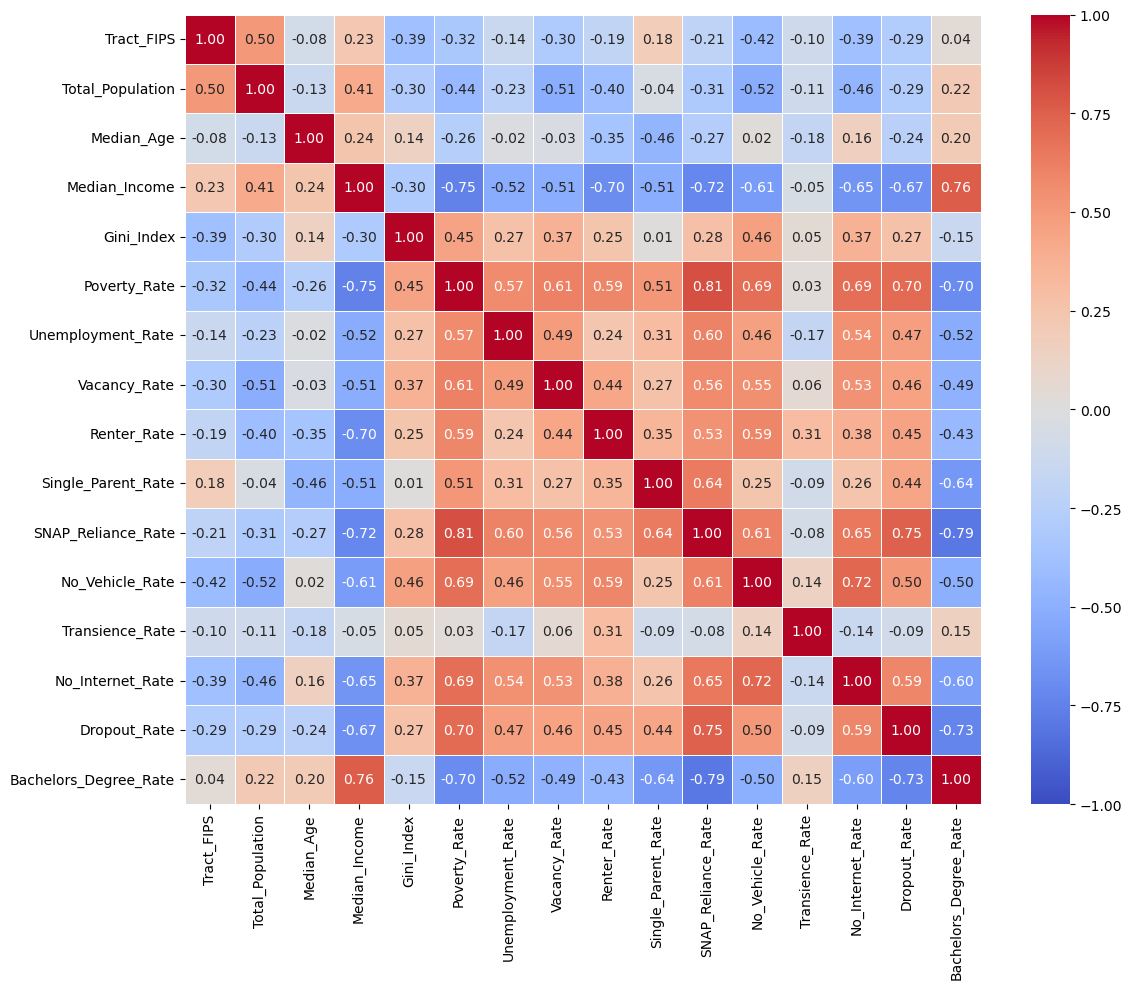

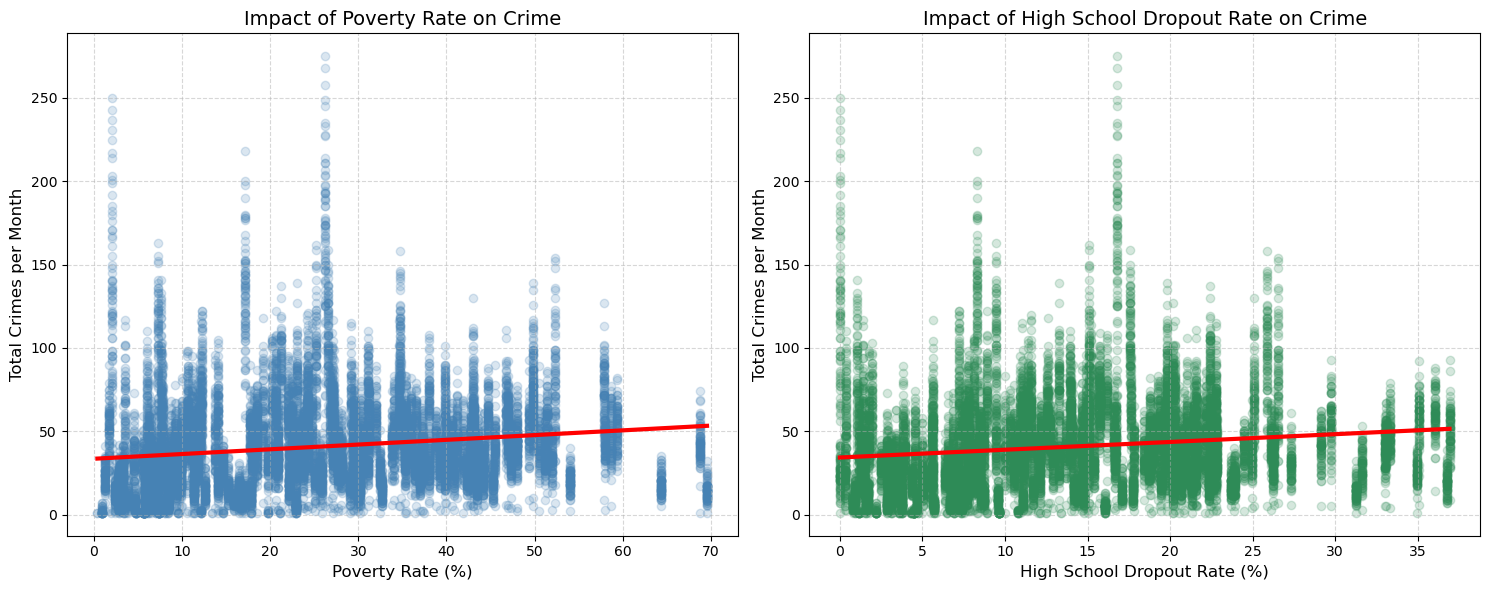

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load master dataset
df = pd.read_csv("memphis_crime_predictors_dataset.csv")

#calculate Correlation with the Target Variable
numeric_features = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_features.corr()

#isolate how everything correlates specifically to 'Total_Crime_Count'
target_corr = corr_matrix[['Total_Crime_Count']].sort_values(by='Total_Crime_Count', ascending=False)

print("Feature Correlation with Crime Counter per Month:")
print(target_corr)

#plot the Correlation Heatmap
plt.figure(figsize=(12, 10))
#drop the Target variable from the heatmap
feature_corr = numeric_features.drop(columns=['Total_Crime_Count']).corr()

sns.heatmap(feature_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()


#plot regression Scatter Plots 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Poverty vs Crime
sns.regplot(data=df, x='Poverty_Rate', y='Total_Crime_Count', ax=axes[0], 
            scatter_kws={'alpha':0.2, 'color': 'steelblue'}, line_kws={'color':'red', 'linewidth': 3})
axes[0].set_title('Impact of Poverty Rate on Crime', fontsize=14)
axes[0].set_xlabel('Poverty Rate (%)', fontsize=12)
axes[0].set_ylabel('Total Crimes per Month', fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

#Dropout Rate vs Crime
sns.regplot(data=df, x='Dropout_Rate', y='Total_Crime_Count', ax=axes[1], 
            scatter_kws={'alpha':0.2, 'color': 'seagreen'}, line_kws={'color':'red', 'linewidth': 3})
axes[1].set_title('Impact of High School Dropout Rate on Crime', fontsize=14)
axes[1].set_xlabel('High School Dropout Rate (%)', fontsize=12)
axes[1].set_ylabel('Total Crimes per Month', fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import geopandas as gpd
import folium

#load master dataset
df = pd.read_csv("memphis_crime_predictors_dataset.csv")

#Group by Tract and calculate the mean crime per month
tract_crime = df.groupby('Tract_FIPS')['Total_Crime_Count'].mean().reset_index()
tract_crime = tract_crime.rename(columns={'Total_Crime_Count': 'Average_Monthly_Crime'})
tract_crime['Tract_FIPS'] = tract_crime['Tract_FIPS'].astype(str)

tracts_url = "zip+https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_47_tract_500k.zip"
tn_tracts = gpd.read_file(tracts_url)
shelby_tracts = tn_tracts[tn_tracts['COUNTYFP'] == '157'].copy()
shelby_tracts['GEOID'] = shelby_tracts['GEOID'].astype(str)

map_data = shelby_tracts.merge(tract_crime, left_on='GEOID', right_on='Tract_FIPS', how='inner')

projected_map = map_data.to_crs(epsg=3857)
centroids_gps = projected_map.geometry.centroid.to_crs(epsg=4326)

map_data['center_lon'] = centroids_gps.x
map_data['center_lat'] = centroids_gps.y
map_data = map_data.to_crs(epsg=4326)

#render map
memphis_map = folium.Map(location=[35.1495, -90.0490], zoom_start=11, tiles="CartoDB dark_matter")

for idx, row in map_data.iterrows():
    #reduce sizing proportionally across all values so map is more readable
    bubble_radius = row['Average_Monthly_Crime'] / 2 
    
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lon']],
        radius=bubble_radius,
        color="crimson",
        weight=1,
        fill=True,
        fill_color="crimson",
        fill_opacity=0.6,
        tooltip=f"<b>Tract FIPS:</b> {row['Tract_FIPS']}<br><b>Historical Avg Monthly Crimes:</b> {row['Average_Monthly_Crime']:.1f}"
    ).add_to(memphis_map)

#save interactive historical map as an html file
memphis_map.save("Memphis_Historical_Avg_Map.html")

#display map
memphis_map

In [17]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

#load master dataset
df = pd.read_csv("memphis_crime_predictors_dataset.csv")

#drop the incomplete final month so it doesn't poison the machine learning model
df = df[df['YearMonth'] != '2026-04']

#extract the month for seasonality
df['Month'] = pd.to_datetime(df['YearMonth']).dt.month

#sort chronologically and calculate what happened in the previous month
df = df.sort_values(by=['Tract_FIPS', 'YearMonth'])
df['Crime_Last_Month'] = df.groupby('Tract_FIPS')['Total_Crime_Count'].shift(1)
df = df.dropna(subset=['Crime_Last_Month'])

features = [
    "Total_Population", "Median_Age", "Median_Income", "Gini_Index", 
    "Poverty_Rate", "Unemployment_Rate", "Vacancy_Rate", "Renter_Rate", 
    "Single_Parent_Rate", "SNAP_Reliance_Rate", "No_Vehicle_Rate", 
    "Transience_Rate", "No_Internet_Rate", "Dropout_Rate", "Bachelors_Degree_Rate",
    "Month", "Crime_Last_Month"  
]
target = "Total_Crime_Count"

#train on out of time split train: 2020-2024, test: 2025-2026
train_data = df[df['YearMonth'] < '2025-01']
test_data = df[df['YearMonth'] >= '2025-01']

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]


print("Tuning hyperparameters")

#define the grid of parameters to test
param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8]
}

#initialize the base model
base_xgb = XGBRegressor(random_state=13, n_jobs=-1)

#set up the Grid Search to test every combination
grid_search = GridSearchCV(
    estimator=base_xgb, 
    param_grid=param_grid, 
    scoring='neg_root_mean_squared_error', 
    cv=3, 
    verbose=1
)

grid_search.fit(X_train, y_train)

#print the best parameters
print(f"\nBest Hyperparameters Found: {grid_search.best_params_}\n")

#use winning model for your predictions
xgb_model = grid_search.best_estimator_

#evaluatie model performance
predictions = xgb_model.predict(X_test)
predictions = np.clip(predictions, 0, None) # No negative crime allowed

#performance metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

baseline_guess = [y_train.mean()] * len(y_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_guess))

print("XGBOOST Performance Metrics:")
print(f"R-Squared (R²):              {r2:.3f}")
print(f"Mean Absolute Error (MAE):   {mae:.2f} crimes per month")
print(f"Root Mean Sq. Error (RMSE):  {rmse:.2f} crimes per month")
print(f"Baseline RMSE:               {baseline_rmse:.2f} crimes per month")
print(f"Improvement vs Baseline:     {((baseline_rmse - rmse) / baseline_rmse) * 100:.1f}%\n")

#isolate the very last recorded month for every single neighborhood
latest_data = df.groupby('Tract_FIPS').tail(1).copy()

#predict next month crime count
latest_data['Crime_Last_Month'] = latest_data['Total_Crime_Count']
latest_data['Month'] = (latest_data['Month'] % 12) + 1
latest_data['Forecasted_Next_Month'] = xgb_model.predict(latest_data[features])
latest_data['Forecasted_Next_Month'] = np.clip(latest_data['Forecasted_Next_Month'], 0, None)

#render new interactive map with next month forecasts
latest_data['Tract_FIPS'] = latest_data['Tract_FIPS'].astype(str)

tracts_url = "zip+https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_47_tract_500k.zip"
tn_tracts = gpd.read_file(tracts_url)
shelby_tracts = tn_tracts[tn_tracts['COUNTYFP'] == '157'].copy()
shelby_tracts['GEOID'] = shelby_tracts['GEOID'].astype(str)

#map math
map_data = shelby_tracts.merge(latest_data, left_on='GEOID', right_on='Tract_FIPS', how='inner')
projected_map = map_data.to_crs(epsg=3857)
centroids_gps = projected_map.geometry.centroid.to_crs(epsg=4326)

map_data['center_lon'] = centroids_gps.x
map_data['center_lat'] = centroids_gps.y
map_data = map_data.to_crs(epsg=4326)

#draw the Map
predictive_map = folium.Map(location=[35.1495, -90.0490], zoom_start=11, tiles="CartoDB dark_matter")

for idx, row in map_data.iterrows():
    #scale bubble radius to be more readable
    bubble_radius = row['Forecasted_Next_Month'] / 2  
    
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lon']],
        radius=bubble_radius,
        color="#00ffcc",  #change color to be different from original historical map
        weight=1,
        fill=True,
        fill_color="#00ffcc",
        fill_opacity=0.6,
        tooltip=f"<b>Tract FIPS:</b> {row['Tract_FIPS']}<br><b>Next Month Forecast:</b> {row['Forecasted_Next_Month']:.1f} crimes"
    ).add_to(predictive_map)

#save the interactive map as an html file
predictive_map.save("Memphis_Future_Forecast_Map.html")

#display in notebook
predictive_map

Tuning hyperparameters
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Hyperparameters Found: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}

XGBOOST Performance Metrics:
R-Squared (R²):              0.771
Mean Absolute Error (MAE):   7.97 crimes per month
Root Mean Sq. Error (RMSE):  10.44 crimes per month
Baseline RMSE:               23.70 crimes per month
Improvement vs Baseline:     56.0%

